# Load lại LightGBM v1 và đánh giá mô hình sau khi Colab bị ngắt

Notebook này dùng khi bạn **đã train xong LightGBM**, model đã lưu trong Google Drive, nhưng Colab bị disconnect.

Notebook sẽ làm các việc chính:

1. Mount Google Drive và authenticate GCP.
2. Load lại model `.txt` đã lưu.
3. Đọc lại dữ liệu Parquet từ GCS theo batch, tạo memmap để tránh tràn RAM.
4. Tạo lại validation split giống lúc train: `test_size=0.15`, `random_state=42`, `stratify=label`.
5. Predict validation theo batch.
6. Tính các chỉ số quan trọng: AUC, Average Precision, Logloss, Precision/Recall/F1 theo threshold, confusion matrix, feature importance.
7. Nếu có metadata `user_id`, `app_id`, `als_score`, `als_rank`, tính thêm Recall@K, NDCG@K, HitRate@K, MAP@K và so sánh ALS baseline với LightGBM rerank.

> Chỉ cần sửa các biến ở phần **Config** nếu đường dẫn của bạn khác.


In [ ]:
# =========================================
# 1. Install libraries
# =========================================
!pip install -q lightgbm pyarrow gcsfs scikit-learn pandas matplotlib

In [ ]:
# =========================================
# 2. Authenticate Google Cloud and mount Drive
# =========================================
from google.colab import auth, drive

auth.authenticate_user()
drive.mount('/content/drive')

print('Authenticated and Drive mounted.')

Mounted at /content/drive
Authenticated and Drive mounted.


In [ ]:
# =========================================
# 3. Imports
# =========================================
import os
import gc
import glob
import json
import numpy as np
import pandas as pd
import gcsfs
import pyarrow.parquet as pq
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', 200)

In [ ]:
# =========================================
# 4. Config - sửa ở đây nếu cần
# =========================================
PROJECT_ID = 'project-79499e5c-69d7-42b8-864'
BUCKET = 'truong_bigdata_24032026_init'

# Folder chứa các parquet numeric-only đã export từ BigQuery.
# Không thêm gs:// ở đầu vì gcsfs dùng dạng bucket/path.
GCS_PREFIX = 'truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v1_16m_numeric/'

# Folder Drive lưu model và output đánh giá.
DRIVE_OUT_DIR = '/content/drive/MyDrive/Steam_Hybrid_Recommender_Demo'
os.makedirs(DRIVE_OUT_DIR, exist_ok=True)

# Model đã train xong và lưu từ notebook trước.
MODEL_PATH = f'{DRIVE_OUT_DIR}/lgbm_v1_16m_colab_cpu_memmap_model.txt'

# Memmap folder trên ổ tạm Colab.
MEMMAP_DIR = '/content/lgbm_eval_memmap'
os.makedirs(MEMMAP_DIR, exist_ok=True)

# Split phải giống lúc train.
VALID_SIZE = 0.15
RANDOM_STATE = 42

print('PROJECT_ID:', PROJECT_ID)
print('GCS_PREFIX:', GCS_PREFIX)
print('DRIVE_OUT_DIR:', DRIVE_OUT_DIR)
print('MODEL_PATH:', MODEL_PATH)
print('Model exists:', os.path.exists(MODEL_PATH))

PROJECT_ID: project-79499e5c-69d7-42b8-864
GCS_PREFIX: truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v1_16m_numeric/
DRIVE_OUT_DIR: /content/drive/MyDrive/Steam_Hybrid_Recommender_Demo
MODEL_PATH: /content/drive/MyDrive/Steam_Hybrid_Recommender_Demo/lgbm_v1_16m_colab_cpu_memmap_model.txt
Model exists: True


In [ ]:
# =========================================
# 5. Nếu model path sai, tìm model trong Drive
# =========================================
if not os.path.exists(MODEL_PATH):
    print('Không thấy model ở MODEL_PATH. Đang tìm các file model LightGBM trong Drive...')
    !find /content/drive/MyDrive -name '*lgbm*model*.txt' -type f
    raise FileNotFoundError('Hãy sửa MODEL_PATH theo file tìm được ở output bên trên.')

In [ ]:
# =========================================
# 6. Feature columns - phải giống notebook train
# =========================================
id_cols = ['user_id', 'app_id', 'user_idx', 'app_idx']
target_col = 'label'

feature_cols = [
    'als_score',
    'als_rank',
    'als_inverse_rank',
    'als_rank_log',

    'language_score',
    'has_language_match',
    'matched_language_count',

    'user_activity_score',
    'user_weight',
    'user_reviews_log',
    'user_products_log',

    'platform_score',
    'steam_deck_score',

    'positive_ratio',
    'positive_review_share',
    'review_count_final',
    'avg_recommendation_hours',

    'price_final_clean',
    'discount',
    'is_free',

    'quality_score',
    'popularity_score',
    'engagement_score',
    'price_attractiveness_score',
    'recency_score',
    'game_profile_score',

    'als_x_language_score',
    'als_x_popularity_score',
    'als_x_quality_score',
    'user_activity_x_game_engagement',
]

all_cols = [target_col] + feature_cols

print('Number of features:', len(feature_cols))
print(feature_cols)

Number of features: 30
['als_score', 'als_rank', 'als_inverse_rank', 'als_rank_log', 'language_score', 'has_language_match', 'matched_language_count', 'user_activity_score', 'user_weight', 'user_reviews_log', 'user_products_log', 'platform_score', 'steam_deck_score', 'positive_ratio', 'positive_review_share', 'review_count_final', 'avg_recommendation_hours', 'price_final_clean', 'discount', 'is_free', 'quality_score', 'popularity_score', 'engagement_score', 'price_attractiveness_score', 'recency_score', 'game_profile_score', 'als_x_language_score', 'als_x_popularity_score', 'als_x_quality_score', 'user_activity_x_game_engagement']


In [ ]:
# =========================================
# 7. Load LightGBM model
# =========================================
model = lgb.Booster(model_file=MODEL_PATH)

best_iter = model.best_iteration
if best_iter is None or best_iter <= 0:
    best_iter = model.num_trees()

print('Loaded model:', MODEL_PATH)
print('Best iteration:', model.best_iteration)
print('Num trees:', model.num_trees())
print('Num features in model:', model.num_feature())
print('Using num_iteration for predict:', best_iter)

if model.num_feature() != len(feature_cols):
    print('WARNING: Số feature của model khác feature_cols. Hãy kiểm tra lại feature_cols.')

Loaded model: /content/drive/MyDrive/Steam_Hybrid_Recommender_Demo/lgbm_v1_16m_colab_cpu_memmap_model.txt
Best iteration: -1
Num trees: 500
Num features in model: 30
Using num_iteration for predict: 500


In [ ]:
# =========================================
# 8. List parquet files on GCS
# =========================================
fs = gcsfs.GCSFileSystem(project=PROJECT_ID)

parquet_files = sorted(fs.glob(GCS_PREFIX + '*.parquet'))
if len(parquet_files) == 0:
    parquet_files = sorted(fs.glob(GCS_PREFIX + '**/*.parquet'))

print('Found parquet files:', len(parquet_files))
for f in parquet_files[:10]:
    print(f)

if len(parquet_files) == 0:
    raise FileNotFoundError(f'No parquet files found under gs://{GCS_PREFIX}')

Found parquet files: 167
truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v1_16m_numeric/000000000000.parquet
truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v1_16m_numeric/000000000001.parquet
truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v1_16m_numeric/000000000002.parquet
truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v1_16m_numeric/000000000003.parquet
truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v1_16m_numeric/000000000004.parquet
truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v1_16m_numeric/000000000005.parquet
truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v1_16m_numeric/000000000006.parquet
truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v1_16m_numeric/000000000007.parquet
truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v1_16m_numeric/000000000008.parquet
truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v1_16m_numeric/000000000009.parquet


In [ ]:
# =========================================
# 9. Check schema and required columns
# =========================================
with fs.open(parquet_files[0], 'rb') as file_obj:
    pf = pq.ParquetFile(file_obj)
    available_cols = set(pf.schema.names)
    print('Rows in first file:', pf.metadata.num_rows)
    print('Number of columns in first file:', len(pf.schema.names))
    print('First 80 columns:')
    print(pf.schema.names[:80])

missing_cols = [c for c in all_cols if c not in available_cols]
if missing_cols:
    raise ValueError(f'Missing required train/eval columns: {missing_cols}')

meta_cols_candidate = ['user_id', 'app_id', 'label', 'als_score', 'als_rank']
meta_cols_existing = [c for c in meta_cols_candidate if c in available_cols]

print('All required feature columns exist.')
print('Metadata columns available:', meta_cols_existing)

Rows in first file: 100800
Number of columns in first file: 66
First 80 columns:
['user_id', 'app_id', 'user_idx', 'app_idx', 'label', 'als_score', 'als_rank', 'als_inverse_rank', 'als_rank_log', 'user_products_raw', 'user_reviews_raw', 'user_products_owned', 'user_reviews_count', 'user_products_log', 'user_reviews_log', 'user_review_density', 'user_activity_score', 'user_weight', 'user_has_enough_signal', 'user_is_outlier', 'days_since_release', 'game_win', 'game_mac', 'game_linux', 'platform_count', 'is_cross_platform', 'platform_score', 'steam_deck', 'steam_deck_score', 'game_rating', 'positive_ratio', 'positive_review_share', 'user_reviews', 'user_reviews_final', 'review_count_all_reviews', 'review_count_final', 'positive_review_count', 'negative_review_count', 'recommendation_event_count', 'recommendation_event_count_final', 'avg_recommendation_hours', 'avg_helpful', 'avg_funny', 'recommended_count', 'price_final', 'price_original', 'price_final_clean', 'price_original_clean', 'di

In [ ]:
# =========================================
# 10. Count total rows without loading full data
# =========================================
total_rows = 0

for i, f in enumerate(parquet_files, start=1):
    with fs.open(f, 'rb') as file_obj:
        pf = pq.ParquetFile(file_obj)
        total_rows += pf.metadata.num_rows
    if i % 20 == 0:
        print(f'Checked {i}/{len(parquet_files)} files, rows so far: {total_rows:,}')

n_rows = total_rows
n_features = len(feature_cols)

print('Total rows:', f'{n_rows:,}')
print('Number of features:', n_features)

Checked 20/167 files, rows so far: 2,017,286
Checked 40/167 files, rows so far: 4,034,123
Checked 60/167 files, rows so far: 6,051,770
Checked 80/167 files, rows so far: 8,069,185
Checked 100/167 files, rows so far: 10,086,619
Checked 120/167 files, rows so far: 12,106,755
Checked 140/167 files, rows so far: 14,123,852
Checked 160/167 files, rows so far: 16,140,767
Total rows: 16,846,271
Number of features: 30


In [ ]:
# =========================================
# 11. Create memmap files
# =========================================
X_path = f'{MEMMAP_DIR}/X_float32.dat'
y_path = f'{MEMMAP_DIR}/y_int8.dat'

# Ghi đè memmap cũ nếu có.
X_mm = np.memmap(X_path, dtype='float32', mode='w+', shape=(n_rows, n_features))
y_mm = np.memmap(y_path, dtype='int8', mode='w+', shape=(n_rows,))

print('Memmap created:')
print('X:', X_mm.shape, X_mm.dtype, X_path)
print('y:', y_mm.shape, y_mm.dtype, y_path)

Memmap created:
X: (16846271, 30) float32 /content/lgbm_eval_memmap/X_float32.dat
y: (16846271,) int8 /content/lgbm_eval_memmap/y_int8.dat


In [ ]:
# =========================================
# 12. Read parquet by batches into memmap
# =========================================
batch_size = 100_000
row_cursor = 0

for file_idx, f in enumerate(parquet_files, start=1):
    print(f'\n[{file_idx}/{len(parquet_files)}] Reading: {f}')

    with fs.open(f, 'rb') as file_obj:
        pf = pq.ParquetFile(file_obj)

        for batch in pf.iter_batches(batch_size=batch_size, columns=all_cols):
            pdf = batch.to_pandas()

            y_batch = (
                pd.to_numeric(pdf[target_col], errors='coerce')
                .fillna(0)
                .astype('int8')
                .to_numpy()
            )

            X_cols = []
            for c in feature_cols:
                arr = pd.to_numeric(pdf[c], errors='coerce').astype('float32').to_numpy()
                arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0).astype('float32')
                X_cols.append(arr)

            X_batch = np.column_stack(X_cols).astype('float32')
            n = len(pdf)

            X_mm[row_cursor:row_cursor+n, :] = X_batch
            y_mm[row_cursor:row_cursor+n] = y_batch
            row_cursor += n

            del pdf, X_batch, X_cols, y_batch, batch
            gc.collect()

    X_mm.flush()
    y_mm.flush()
    print('Rows loaded so far:', f'{row_cursor:,}')

print('Done.')
print('Total loaded rows:', f'{row_cursor:,}')
assert row_cursor == n_rows, 'Loaded row count mismatch.'


[1/167] Reading: truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v1_16m_numeric/000000000000.parquet
Rows loaded so far: 100,800

[2/167] Reading: truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v1_16m_numeric/000000000001.parquet
Rows loaded so far: 201,513

[3/167] Reading: truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v1_16m_numeric/000000000002.parquet
Rows loaded so far: 302,656

[4/167] Reading: truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v1_16m_numeric/000000000003.parquet
Rows loaded so far: 403,430

[5/167] Reading: truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v1_16m_numeric/000000000004.parquet
Rows loaded so far: 504,110

[6/167] Reading: truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v1_16m_numeric/000000000005.parquet
Rows loaded so far: 605,342

[7/167] Reading: truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v1_16m_numeric/000000000006.parquet
Rows loaded so far: 706,425

[8/16

In [ ]:
# =========================================
# 13. Reopen memmap and recreate train/valid split
# =========================================
X = np.memmap(X_path, dtype='float32', mode='r', shape=(n_rows, n_features))
y = np.memmap(y_path, dtype='int8', mode='r', shape=(n_rows,))

print('X:', X.shape, X.dtype)
print('y:', y.shape, y.dtype)
print('Positive rows:', int(y.sum()))
print('Negative rows:', int(len(y) - y.sum()))
print('Positive rate:', float(y.mean()))

indices = np.arange(n_rows)
train_idx, valid_idx = train_test_split(
    indices,
    test_size=VALID_SIZE,
    random_state=RANDOM_STATE,
    stratify=np.asarray(y)
)

print('Train rows:', f'{len(train_idx):,}')
print('Valid rows:', f'{len(valid_idx):,}')

X: (16846271, 30) float32
y: (16846271,) int8
Positive rows: 1425281
Negative rows: 15420990
Positive rate: 0.08460513308850368
Train rows: 14,319,330
Valid rows: 2,526,941


In [ ]:
# =========================================
# 14. Predict validation by batch
# =========================================
valid_y = y[valid_idx].astype('int8')
valid_pred = np.empty(len(valid_idx), dtype='float32')

predict_batch_size = 200_000

for start in range(0, len(valid_idx), predict_batch_size):
    end = min(start + predict_batch_size, len(valid_idx))
    idx_batch = valid_idx[start:end]

    X_batch = X[idx_batch]
    pred_batch = model.predict(X_batch, num_iteration=best_iter).astype('float32')
    valid_pred[start:end] = pred_batch

    print(f'Predicted {end:,}/{len(valid_idx):,}')

    del X_batch, pred_batch
    gc.collect()

print('valid_pred:', valid_pred.shape)
print('min:', float(valid_pred.min()))
print('max:', float(valid_pred.max()))
print('mean:', float(valid_pred.mean()))
print('std:', float(valid_pred.std()))

Predicted 200,000/2,526,941
Predicted 400,000/2,526,941
Predicted 600,000/2,526,941
Predicted 800,000/2,526,941
Predicted 1,000,000/2,526,941
Predicted 1,200,000/2,526,941
Predicted 1,400,000/2,526,941
Predicted 1,600,000/2,526,941
Predicted 1,800,000/2,526,941
Predicted 2,000,000/2,526,941
Predicted 2,200,000/2,526,941
Predicted 2,400,000/2,526,941
Predicted 2,526,941/2,526,941
valid_pred: (2526941,)
min: 0.02295248955488205
max: 0.9340336322784424
mean: 0.43490365147590637
std: 0.17856164276599884


In [ ]:
# =========================================
# 15. Save valid_pred and valid_idx for reuse
# =========================================
valid_pred_path = f'{DRIVE_OUT_DIR}/valid_pred_lgbm_v1_loaded_eval.npy'
valid_idx_path = f'{DRIVE_OUT_DIR}/valid_idx_lgbm_v1_loaded_eval.npy'
valid_y_path = f'{DRIVE_OUT_DIR}/valid_y_lgbm_v1_loaded_eval.npy'

np.save(valid_pred_path, valid_pred)
np.save(valid_idx_path, valid_idx)
np.save(valid_y_path, valid_y)

print('Saved:', valid_pred_path)
print('Saved:', valid_idx_path)
print('Saved:', valid_y_path)

Saved: /content/drive/MyDrive/Steam_Hybrid_Recommender_Demo/valid_pred_lgbm_v1_loaded_eval.npy
Saved: /content/drive/MyDrive/Steam_Hybrid_Recommender_Demo/valid_idx_lgbm_v1_loaded_eval.npy
Saved: /content/drive/MyDrive/Steam_Hybrid_Recommender_Demo/valid_y_lgbm_v1_loaded_eval.npy


## Các chỉ số classification/ranking cơ bản

Phần này không cần metadata `user_id`. Đây là các chỉ số chắc chắn tính được sau khi có `valid_y` và `valid_pred`.


In [ ]:
# =========================================
# 16. AUC, Average Precision, Logloss
# =========================================
auc = roc_auc_score(valid_y, valid_pred)
ap = average_precision_score(valid_y, valid_pred)
ll = log_loss(valid_y, valid_pred)

metrics_df = pd.DataFrame([{
    'model': 'lightgbm_v1_16m_loaded_eval',
    'rows': int(n_rows),
    'features': int(len(feature_cols)),
    'best_iteration_used': int(best_iter),
    'valid_auc': float(auc),
    'valid_average_precision': float(ap),
    'valid_logloss': float(ll),
    'positive_rate': float(y.mean()),
    'ap_over_random_baseline': float(ap / max(float(y.mean()), 1e-12)),
}])

display(metrics_df)

metrics_path = f'{DRIVE_OUT_DIR}/metrics_lgbm_v1_loaded_eval.csv'
metrics_df.to_csv(metrics_path, index=False)
print('Saved:', metrics_path)

,model,rows,features,best_iteration_used,valid_auc,valid_average_precision,valid_logloss,positive_rate,ap_over_random_baseline
0,lightgbm_v1_16m_loaded_eval,16846271,30,500,0.731853,0.223341,0.605243,0.084605,2.639805


Saved: /content/drive/MyDrive/Steam_Hybrid_Recommender_Demo/metrics_lgbm_v1_loaded_eval.csv


In [ ]:
# =========================================
# 17. Classification metrics by threshold
# =========================================
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]
rows = []

for th in thresholds:
    y_hat = (valid_pred >= th).astype('int8')
    rows.append({
        'threshold': th,
        'accuracy': accuracy_score(valid_y, y_hat),
        'precision': precision_score(valid_y, y_hat, zero_division=0),
        'recall': recall_score(valid_y, y_hat, zero_division=0),
        'f1': f1_score(valid_y, y_hat, zero_division=0),
        'pred_positive_rate': float(y_hat.mean()),
    })

classification_metrics_df = pd.DataFrame(rows)
display(classification_metrics_df)

classification_path = f'{DRIVE_OUT_DIR}/classification_metrics_lgbm_v1_loaded_eval.csv'
classification_metrics_df.to_csv(classification_path, index=False)
print('Saved:', classification_path)

,threshold,accuracy,precision,recall,f1,pred_positive_rate
0,0.10,0.090168,0.085054,0.999659,0.156770,0.994380
1,0.20,0.146690,0.089404,0.989176,0.163986,0.936084
2,0.30,0.337980,0.106259,0.920904,0.190533,0.733241
3,0.40,0.532580,0.130878,0.802153,0.225039,0.518547
4,0.50,0.685950,0.162213,0.651170,0.259726,0.339629
5,0.55,0.746855,0.181670,0.568436,0.275341,0.264725
6,0.60,0.798329,0.204516,0.478849,0.286618,0.198092
7,0.65,0.837595,0.229821,0.391100,0.289515,0.143978
8,0.70,0.869067,0.261509,0.300212,0.279527,0.097127
9,0.75,0.892327,0.302710,0.209175,0.247397,0.058463


Saved: /content/drive/MyDrive/Steam_Hybrid_Recommender_Demo/classification_metrics_lgbm_v1_loaded_eval.csv


In [ ]:
# =========================================
# 18. Confusion matrix and classification report at threshold 0.5
# =========================================
threshold = 0.5
y_hat = (valid_pred >= threshold).astype('int8')

cm = confusion_matrix(valid_y, y_hat)
cm_df = pd.DataFrame(cm, index=['actual_0', 'actual_1'], columns=['pred_0', 'pred_1'])
display(cm_df)
print(classification_report(valid_y, y_hat, digits=4))

,pred_0,pred_1
actual_0,1594141,719008
actual_1,74577,139215


              precision    recall  f1-score   support

           0     0.9553    0.6892    0.8007   2313149
           1     0.1622    0.6512    0.2597    213792

    accuracy                         0.6860   2526941
   macro avg     0.5588    0.6702    0.5302   2526941
weighted avg     0.8882    0.6860    0.7549   2526941



In [ ]:
# =========================================
# 19. Prediction distribution and score by label
# =========================================
pred_stats = pd.DataFrame({
    'metric': ['min', 'p01', 'p05', 'p10', 'p25', 'p50', 'p75', 'p90', 'p95', 'p99', 'max', 'mean', 'std'],
    'value': [
        np.min(valid_pred),
        np.quantile(valid_pred, 0.01),
        np.quantile(valid_pred, 0.05),
        np.quantile(valid_pred, 0.10),
        np.quantile(valid_pred, 0.25),
        np.quantile(valid_pred, 0.50),
        np.quantile(valid_pred, 0.75),
        np.quantile(valid_pred, 0.90),
        np.quantile(valid_pred, 0.95),
        np.quantile(valid_pred, 0.99),
        np.max(valid_pred),
        np.mean(valid_pred),
        np.std(valid_pred),
    ]
})

display(pred_stats)

score_by_label_df = pd.DataFrame({'label': valid_y, 'lgbm_score': valid_pred})
score_summary_by_label = score_by_label_df.groupby('label')['lgbm_score'].agg(
    ['count', 'mean', 'std', 'min', 'median', 'max']
).reset_index()

display(score_summary_by_label)

pred_stats.to_csv(f'{DRIVE_OUT_DIR}/prediction_distribution_lgbm_v1_loaded_eval.csv', index=False)
score_summary_by_label.to_csv(f'{DRIVE_OUT_DIR}/score_by_label_lgbm_v1_loaded_eval.csv', index=False)

,metric,value
0,min,0.022952
1,p01,0.119775
2,p05,0.188516
3,p10,0.222838
4,p25,0.292747
5,p50,0.409528
6,p75,0.560677
7,p90,0.696536
8,p95,0.763908
9,p99,0.853881


,label,count,mean,std,min,median,max
0,0,2313149,0.421675,0.172251,0.022952,0.396193,0.934034
1,1,213792,0.578039,0.182911,0.037517,0.588664,0.934034


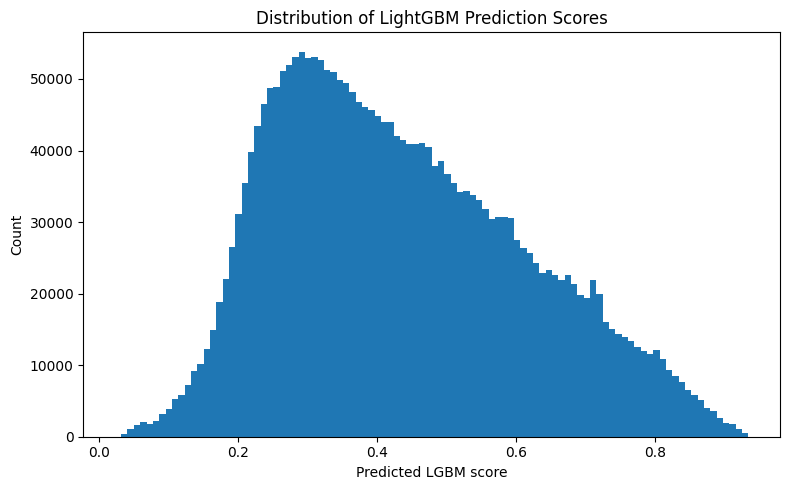

Saved: /content/drive/MyDrive/Steam_Hybrid_Recommender_Demo/prediction_distribution_lgbm_v1_loaded_eval.png


In [ ]:
# =========================================
# 20. Plot prediction distribution
# =========================================
plt.figure(figsize=(8, 5))
plt.hist(valid_pred, bins=100)
plt.xlabel('Predicted LGBM score')
plt.ylabel('Count')
plt.title('Distribution of LightGBM Prediction Scores')
plt.tight_layout()

fig_path = f'{DRIVE_OUT_DIR}/prediction_distribution_lgbm_v1_loaded_eval.png'
plt.savefig(fig_path, dpi=200)
plt.show()

print('Saved:', fig_path)

In [ ]:
# =========================================
# 21. Feature importance
# =========================================
fi = pd.DataFrame({
    'feature': feature_cols,
    'importance_gain': model.feature_importance(importance_type='gain'),
    'importance_split': model.feature_importance(importance_type='split'),
}).sort_values('importance_gain', ascending=False)

display(fi.head(30))

fi_path = f'{DRIVE_OUT_DIR}/feature_importance_lgbm_v1_loaded_eval.csv'
fi.to_csv(fi_path, index=False)
print('Saved:', fi_path)

,feature,importance_gain,importance_split
0,als_score,1.580729e+07,765
27,als_x_popularity_score,1.453056e+07,556
28,als_x_quality_score,7.243105e+06,479
25,game_profile_score,3.606365e+06,2613
24,recency_score,3.228059e+06,2397
4,language_score,3.034466e+06,2451
17,price_final_clean,2.258011e+06,1498
13,positive_ratio,1.608950e+06,1540
1,als_rank,1.470121e+06,850
26,als_x_language_score,4.927767e+05,427


Saved: /content/drive/MyDrive/Steam_Hybrid_Recommender_Demo/feature_importance_lgbm_v1_loaded_eval.csv


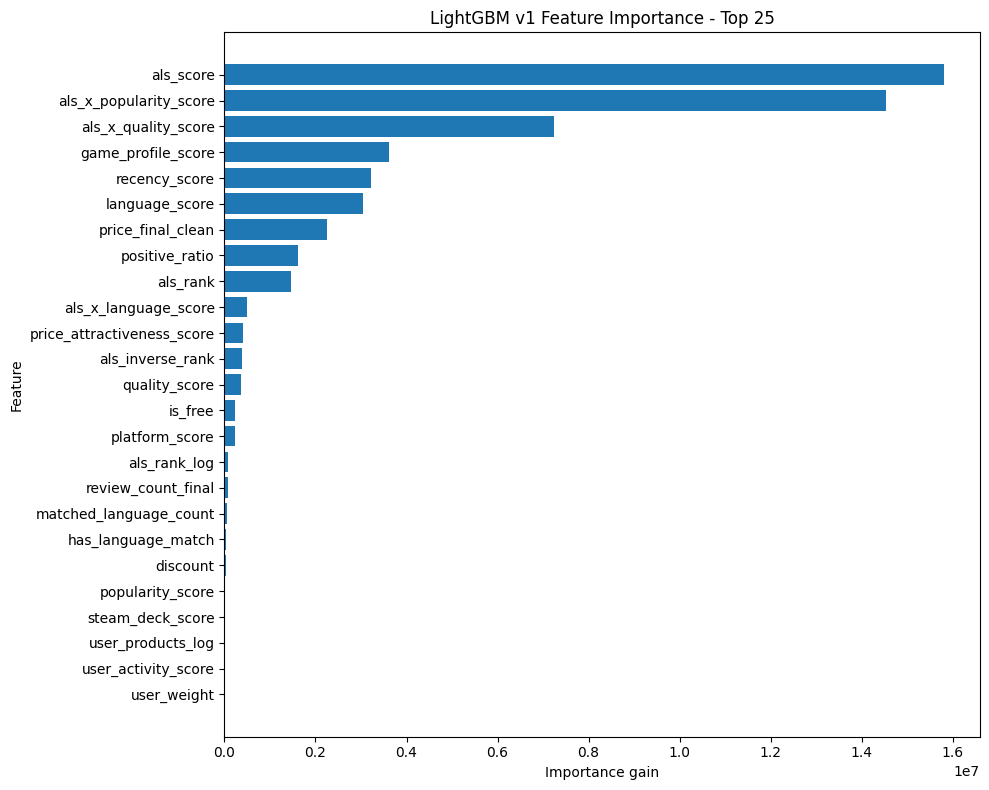

Saved: /content/drive/MyDrive/Steam_Hybrid_Recommender_Demo/feature_importance_lgbm_v1_loaded_eval.png


In [ ]:
# =========================================
# 22. Plot feature importance
# =========================================
top_fi = fi.head(25).sort_values('importance_gain', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(top_fi['feature'], top_fi['importance_gain'])
plt.xlabel('Importance gain')
plt.ylabel('Feature')
plt.title('LightGBM v1 Feature Importance - Top 25')
plt.tight_layout()

fig_path = f'{DRIVE_OUT_DIR}/feature_importance_lgbm_v1_loaded_eval.png'
plt.savefig(fig_path, dpi=200)
plt.show()

print('Saved:', fig_path)

## Ranking metrics: Recall@K, NDCG@K, HitRate@K, MAP@K

Phần này là quan trọng nhất cho hệ recommendation. Nó cần có metadata theo từng candidate, ít nhất:

- `user_id`
- `label`
- `lgbm_score`

Nếu có thêm `als_score` hoặc `als_rank`, notebook sẽ so sánh ALS baseline với LightGBM rerank.


In [ ]:
# =========================================
# 23. Read metadata for validation ranking metrics
# =========================================
meta_cols_candidate = ['user_id', 'app_id', 'label', 'als_score', 'als_rank']
meta_cols_existing = [c for c in meta_cols_candidate if c in available_cols]

print('Metadata columns available:', meta_cols_existing)

if 'user_id' not in meta_cols_existing:
    print('Không có user_id trong parquet. Bỏ qua ranking metrics theo user.')
    df_meta = None
else:
    meta_parts = []
    row_cursor = 0

    for file_idx, f in enumerate(parquet_files, start=1):
        print(f'\n[{file_idx}/{len(parquet_files)}] Reading metadata: {f}')
        with fs.open(f, 'rb') as file_obj:
            pf = pq.ParquetFile(file_obj)
            for batch in pf.iter_batches(batch_size=200_000, columns=meta_cols_existing):
                pdf = batch.to_pandas()
                meta_parts.append(pdf)
                row_cursor += len(pdf)
                if row_cursor % 1_000_000 < 200_000:
                    print('Metadata rows loaded:', f'{row_cursor:,}')
                del pdf, batch
                gc.collect()

    df_meta = pd.concat(meta_parts, ignore_index=True)
    print('df_meta:', df_meta.shape)
    display(df_meta.head())

Metadata columns available: ['user_id', 'app_id', 'label', 'als_score', 'als_rank']

[1/167] Reading metadata: truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v1_16m_numeric/000000000000.parquet
Metadata rows loaded: 100,800

[2/167] Reading metadata: truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v1_16m_numeric/000000000001.parquet

[3/167] Reading metadata: truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v1_16m_numeric/000000000002.parquet

[4/167] Reading metadata: truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v1_16m_numeric/000000000003.parquet

[5/167] Reading metadata: truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v1_16m_numeric/000000000004.parquet

[6/167] Reading metadata: truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v1_16m_numeric/000000000005.parquet

[7/167] Reading metadata: truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v1_16m_numeric/000000000006.parquet

[8/167] Reading metadata

,user_id,app_id,label,als_score,als_rank
0,76561198131399649,10,0,0.427105,45
1,76561198087284251,10,0,0.429173,37
2,76561198065306207,10,0,0.451150,35
3,76561198312930297,10,0,0.745587,16
4,76561198025799860,10,0,0.638949,32


In [ ]:
# =========================================
# 24. Build valid_eval_df
# =========================================
if df_meta is not None:
    valid_eval_df = df_meta.iloc[valid_idx].reset_index(drop=True)
    valid_eval_df['lgbm_score'] = valid_pred

    print('valid_eval_df:', valid_eval_df.shape)
    display(valid_eval_df.head())
    print(valid_eval_df.columns.tolist())

    valid_eval_path = f'{DRIVE_OUT_DIR}/valid_eval_lgbm_v1_loaded_eval.parquet'
    valid_eval_df.to_parquet(valid_eval_path, index=False)
    print('Saved:', valid_eval_path)
else:
    valid_eval_df = None

valid_eval_df: (2526941, 6)


,user_id,app_id,label,als_score,als_rank,lgbm_score
0,76561198093975220,275850,0,1.109639,7,0.807179
1,76561198317963896,424840,0,0.692460,29,0.530594
2,76561198879675748,433340,1,0.778796,11,0.472120
3,76561198367986644,739630,0,0.603098,31,0.583237
4,76561199174801196,362890,0,0.658493,23,0.484058


['user_id', 'app_id', 'label', 'als_score', 'als_rank', 'lgbm_score']
Saved: /content/drive/MyDrive/Steam_Hybrid_Recommender_Demo/valid_eval_lgbm_v1_loaded_eval.parquet


In [ ]:
# =========================================
# 25. Ranking metric functions
# =========================================
def dcg_at_k(labels):
    labels = np.asarray(labels)
    discounts = np.log2(np.arange(2, len(labels) + 2))
    return np.sum(labels / discounts)


def ndcg_at_k(labels, total_pos, k):
    labels = np.asarray(labels[:k])
    if total_pos == 0:
        return np.nan

    dcg = dcg_at_k(labels)
    ideal_len = min(int(total_pos), k)
    ideal_labels = np.ones(ideal_len)
    idcg = dcg_at_k(ideal_labels)
    return dcg / idcg if idcg > 0 else np.nan


def average_precision_at_k(labels, total_pos, k):
    labels = np.asarray(labels[:k])
    if total_pos == 0:
        return np.nan

    hits = 0
    precisions = []
    for i, rel in enumerate(labels, start=1):
        if rel == 1:
            hits += 1
            precisions.append(hits / i)

    if len(precisions) == 0:
        return 0.0
    return np.sum(precisions) / min(total_pos, k)


def ranking_metrics_at_k(df, score_col, user_col='user_id', label_col='label', ks=[5, 10, 20, 50]):
    results = []

    use_df = df[[user_col, label_col, score_col]].copy()
    use_df[label_col] = use_df[label_col].astype(int)
    use_df = use_df.sort_values([user_col, score_col], ascending=[True, False])

    for k in ks:
        recalls = []
        precisions = []
        hit_rates = []
        ndcgs = []
        maps = []

        for user_id, g in use_df.groupby(user_col, sort=False):
            labels = g[label_col].values
            total_pos = labels.sum()
            if total_pos == 0:
                continue

            topk = labels[:k]
            hits = topk.sum()

            recalls.append(hits / total_pos)
            precisions.append(hits / k)
            hit_rates.append(1.0 if hits > 0 else 0.0)
            ndcgs.append(ndcg_at_k(labels, total_pos, k))
            maps.append(average_precision_at_k(labels, total_pos, k))

        results.append({
            'model': score_col,
            'k': k,
            'num_users_eval': len(recalls),
            'recall_at_k': np.mean(recalls) if recalls else np.nan,
            'precision_at_k': np.mean(precisions) if precisions else np.nan,
            'hit_rate_at_k': np.mean(hit_rates) if hit_rates else np.nan,
            'ndcg_at_k': np.nanmean(ndcgs) if ndcgs else np.nan,
            'map_at_k': np.nanmean(maps) if maps else np.nan,
        })

    return pd.DataFrame(results)

In [ ]:
# =========================================
# 26. LightGBM ranking metrics
# =========================================
if valid_eval_df is not None:
    lgbm_ranking_metrics_df = ranking_metrics_at_k(
        valid_eval_df,
        score_col='lgbm_score',
        user_col='user_id',
        label_col='label',
        ks=[5, 10, 20, 50]
    )

    display(lgbm_ranking_metrics_df)

    ranking_path = f'{DRIVE_OUT_DIR}/ranking_metrics_lgbm_v1_loaded_eval.csv'
    lgbm_ranking_metrics_df.to_csv(ranking_path, index=False)
    print('Saved:', ranking_path)
else:
    print('Bỏ qua ranking metrics vì không có valid_eval_df.')

,model,k,num_users_eval,recall_at_k,precision_at_k,hit_rate_at_k,ndcg_at_k,map_at_k
0,lgbm_score,5,205829,0.999977,0.207725,0.999995,0.916253,0.88650
1,lgbm_score,10,205829,1.000000,0.103869,1.000000,0.916264,0.88651
2,lgbm_score,20,205829,1.000000,0.051934,1.000000,0.916264,0.88651
3,lgbm_score,50,205829,1.000000,0.020774,1.000000,0.916264,0.88651


Saved: /content/drive/MyDrive/Steam_Hybrid_Recommender_Demo/ranking_metrics_lgbm_v1_loaded_eval.csv


In [ ]:
# =========================================
# 27. Compare ALS baseline vs LightGBM rerank
# =========================================
if valid_eval_df is not None:
    compare_parts = []

    if 'als_score' in valid_eval_df.columns:
        als_ranking_metrics_df = ranking_metrics_at_k(
            valid_eval_df,
            score_col='als_score',
            user_col='user_id',
            label_col='label',
            ks=[5, 10, 20, 50]
        )
        compare_parts.append(als_ranking_metrics_df.assign(model_name='ALS_baseline_score'))

    elif 'als_rank' in valid_eval_df.columns:
        valid_eval_df['als_rank_score'] = -valid_eval_df['als_rank']
        als_ranking_metrics_df = ranking_metrics_at_k(
            valid_eval_df,
            score_col='als_rank_score',
            user_col='user_id',
            label_col='label',
            ks=[5, 10, 20, 50]
        )
        compare_parts.append(als_ranking_metrics_df.assign(model_name='ALS_baseline_rank'))

    compare_parts.append(lgbm_ranking_metrics_df.assign(model_name='LGBM_v1_rerank'))

    compare_df = pd.concat(compare_parts, ignore_index=True)
    display(compare_df)

    compare_path = f'{DRIVE_OUT_DIR}/compare_als_vs_lgbm_v1_loaded_eval.csv'
    compare_df.to_csv(compare_path, index=False)
    print('Saved:', compare_path)
else:
    print('Không có valid_eval_df để so sánh ALS vs LGBM.')

,model,k,num_users_eval,recall_at_k,precision_at_k,hit_rate_at_k,ndcg_at_k,map_at_k,model_name
0,als_score,5,205829,0.999970,0.207722,0.999995,0.905498,0.872009,ALS_baseline_score
1,als_score,10,205829,1.000000,0.103869,1.000000,0.905512,0.872022,ALS_baseline_score
2,als_score,20,205829,1.000000,0.051934,1.000000,0.905512,0.872022,ALS_baseline_score
3,als_score,50,205829,1.000000,0.020774,1.000000,0.905512,0.872022,ALS_baseline_score
4,lgbm_score,5,205829,0.999977,0.207725,0.999995,0.916253,0.886500,LGBM_v1_rerank
5,lgbm_score,10,205829,1.000000,0.103869,1.000000,0.916264,0.886510,LGBM_v1_rerank
6,lgbm_score,20,205829,1.000000,0.051934,1.000000,0.916264,0.886510,LGBM_v1_rerank
7,lgbm_score,50,205829,1.000000,0.020774,1.000000,0.916264,0.886510,LGBM_v1_rerank


Saved: /content/drive/MyDrive/Steam_Hybrid_Recommender_Demo/compare_als_vs_lgbm_v1_loaded_eval.csv


## Gợi ý kết luận báo cáo

Sau khi chạy xong, bạn nên chụp màn hình các bảng/file sau:

1. `metrics_df`: AUC, Average Precision, Logloss, positive rate.
2. `classification_metrics_df`: Precision/Recall/F1 theo threshold.
3. `fi.head(30)`: feature importance.
4. `lgbm_ranking_metrics_df`: Recall@K, NDCG@K, HitRate@K, MAP@K.
5. `compare_df`: so sánh ALS baseline với LightGBM rerank.

Với bài recommendation, ưu tiên phân tích **Recall@K, NDCG@K và so sánh ALS vs LightGBM**. Accuracy/F1 chỉ là chỉ số phụ vì hệ thống thực tế sẽ sort top-K candidate thay vì dùng threshold cố định.
